# 🚢 Titanic Exploratory Data Analysis (EDA)

## Project Overview
The Titanic disaster remains one of the most well-known maritime tragedies in history. This project performs an in-depth Exploratory Data Analysis (EDA) on the Titanic dataset to uncover patterns, trends, and relationships that influenced passenger survival.

Using Python and data visualization techniques, we investigate demographic characteristics, socioeconomic factors, and travel information to derive meaningful insights from the data.

---

## Objectives

- Understand the structure and quality of the dataset.
- Perform statistical exploration of the data.
- Identify missing values and potential data quality issues.
- Analyze the distribution of important features.
- Investigate relationships between variables and survival outcomes.
- Detect trends, patterns, and anomalies using visualizations.
- Summarize key findings through data-driven insights.

---

## Tools and Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

### Dataset
**Source:** Kaggle – Titanic: Machine Learning from Disaster

**Dataset Used:** `train.csv`

---

**Author:** Yasodha Krishna Sajja

**Date:** June 2026

# 1. Importing Required Libraries

The following libraries are imported to facilitate data manipulation, statistical exploration, and visualization throughout the analysis.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots within the notebook
%matplotlib inline

# Improve the appearance of visualizations
sns.set_style("whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


# 2. Loading the Dataset

In this section, the Titanic dataset is loaded into a Pandas DataFrame for analysis.

In [3]:
df = pd.read_csv(r"C:\Users\krish\Downloads\titanic\train.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# 3. Initial Data Exploration

Before conducting any analysis, it is essential to understand the structure and contents of the dataset.

The following steps provide an overview of the data, including the number of records, available features, and a preview of the dataset.

In [4]:
# Display the first five rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Data Understanding

Understanding the dataset is a crucial first step in Exploratory Data Analysis (EDA). This section examines the dataset's dimensions, data types, missing values, and statistical summaries to assess data quality and identify areas requiring further investigation.

The insights gathered here will guide subsequent analyses and preprocessing decisions.

In [5]:
# Display the number of rows and columns

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 891
Number of Columns: 12


### Insight

The Titanic dataset contains information on **891 passengers** described by **12 features**. These features include demographic details, ticket information, and survival outcomes.

In [6]:
# View all feature names

print("Features in the dataset:")
df.columns.tolist()

Features in the dataset:


['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

The dataset consists of a mix of numerical and categorical variables. Features such as **Age**, **Fare**, and **Passenger Class** may play an important role in understanding survival patterns.

### Category Frequency Analysis

The `value_counts()` function provides a quick overview of the distribution of categorical variables and helps identify class imbalances within the dataset.

In [7]:
# Survival distribution
print("Survival Counts:")
print(df['Survived'].value_counts())

print("\n" + "-"*40 + "\n")

# Gender distribution
print("Gender Counts:")
print(df['Sex'].value_counts())

print("\n" + "-"*40 + "\n")

# Passenger Class distribution
print("Passenger Class Counts:")
print(df['Pclass'].value_counts())

Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64

----------------------------------------

Gender Counts:
Sex
male      577
female    314
Name: count, dtype: int64

----------------------------------------

Passenger Class Counts:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [8]:
# Examine data types and missing values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Initial Observations

- The dataset contains both numerical and categorical variables.
- Some features contain missing values that may require attention.
- The `Cabin` feature appears to have a substantial number of missing entries.
- The `Age` feature also contains missing values and may require imputation during preprocessing.

In [9]:
# Generate descriptive statistics for numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### Statistical Insights

- The average passenger age was approximately 30 years.
- Passenger fares exhibit considerable variability, indicating differences in ticket classes and accommodations.
- The dataset includes both children and elderly passengers.
- Survival rates suggest that more passengers did not survive than those who did.

# 5. Data Quality Checks and Cleaning

Real-world datasets often contain inconsistencies such as missing values, duplicate records, and incorrect data types. Before proceeding with exploratory analysis, these issues must be assessed and addressed appropriately.

Since the objective of this project is Exploratory Data Analysis (EDA) rather than predictive modeling, only minimal cleaning techniques are applied to preserve the authenticity of the data.

In [10]:
# Check the number of missing values in each column

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': round((missing_values / len(df)) * 100, 2)
})

missing_df[missing_df['Missing Values'] > 0].sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values,Percentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### Missing Value Assessment

The dataset contains missing values in three features:

- **Cabin:** Approximately 77% missing values.
- **Age:** Approximately 20% missing values.
- **Embarked:** Less than 1% missing values.

Appropriate treatment strategies will be applied based on the extent and nature of missingness.

In [11]:
# Check for duplicate records

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


### Duplicate Record Assessment

No duplicate records were identified in the dataset. Each observation appears to represent a unique passenger.

In [12]:
# Display data types of all features

df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

### Data Type Assessment

The data types of all variables were reviewed and found suitable for exploratory analysis.

- Numerical variables include Age, Fare, SibSp, and Parch.
- Categorical variables include Sex and Embarked.
- Passenger Class (Pclass) is stored as an integer but represents categorical information.

In [13]:
# Fill missing Age values using the median

df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values using the mode

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing values treated successfully.")

Missing values treated successfully.


In [14]:
# Recheck missing values after treatment

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

### Data Cleaning Insights

- Median imputation was applied to the Age feature to minimize the influence of extreme values.
- Mode imputation was used for Embarked due to the negligible number of missing observations.
- The Cabin feature was retained without imputation because the large proportion of missing values (~77%) could introduce substantial bias if artificially filled.
- Duplicate records were not present in the dataset.
- The cleaning process was intentionally conservative to preserve the integrity of the original data during exploratory analysis.

# 6. Univariate Analysis

Univariate analysis focuses on examining individual variables independently to understand their distributions, central tendencies, and potential anomalies.

This analysis provides valuable insights into passenger demographics and characteristics before investigating relationships between variables.

## 6.1 Survival Distribution

This analysis examines the distribution of survival outcomes among Titanic passengers.

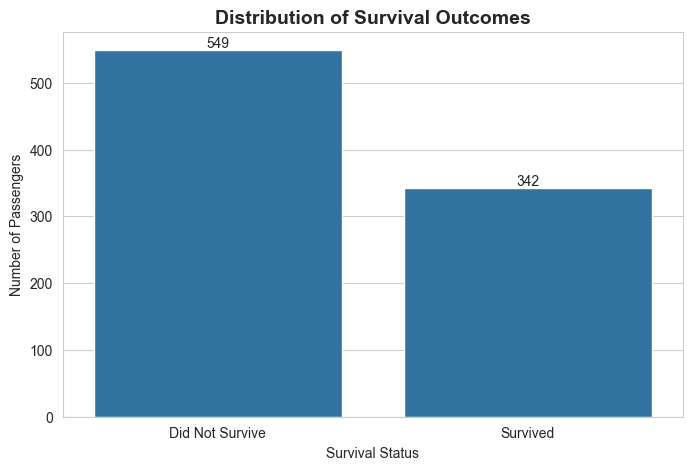

In [15]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Survived',
    data=df
)

plt.title('Distribution of Survival Outcomes', fontsize=14, fontweight='bold')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')

plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observations

- The number of passengers who did not survive exceeded those who survived.
- Approximately 62% of passengers did not survive, while around 38% survived.
- The dataset exhibits class imbalance toward non-survivors.
- This imbalance should be considered in future predictive modeling tasks.

## 6.2 Age Distribution

Understanding the age profile of passengers helps identify demographic patterns within the dataset.

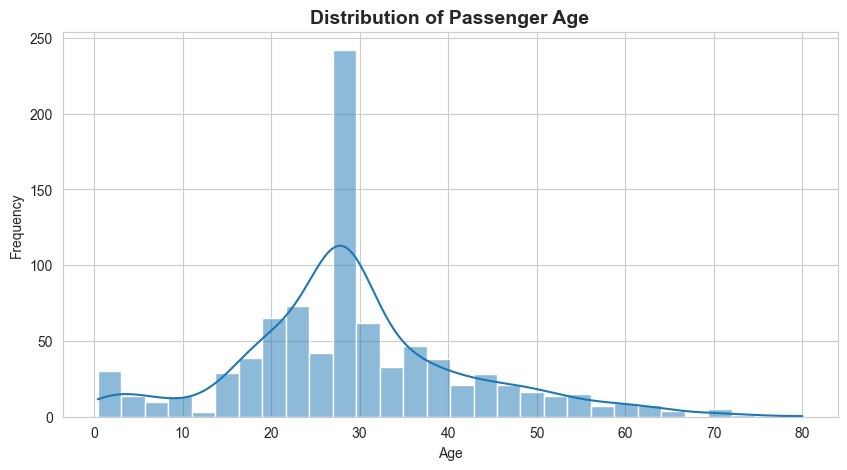

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title('Distribution of Passenger Age', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

### Observations

- Most passengers were between 20 and 40 years of age.
- The age distribution is slightly right-skewed.
- Children and elderly passengers represented a smaller proportion of the population.
- The median age imputation ensured complete representation of passengers.

## 6.3 Fare Distribution

Fare provides insight into the economic diversity of passengers aboard the Titanic.

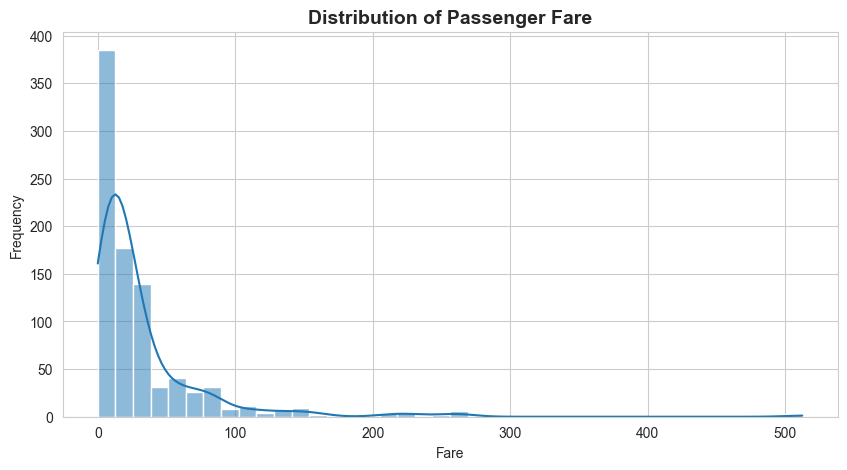

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Fare'],
    bins=40,
    kde=True
)

plt.title('Distribution of Passenger Fare', fontsize=14, fontweight='bold')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

### Observations

- Fare distribution is highly right-skewed.
- Most passengers paid relatively low fares.
- A small number of passengers paid substantially higher fares.
- The presence of extreme values suggests socioeconomic disparities among passengers.

## 6.4 Passenger Class Distribution

Passenger class reflects differences in socioeconomic status and travel accommodations.

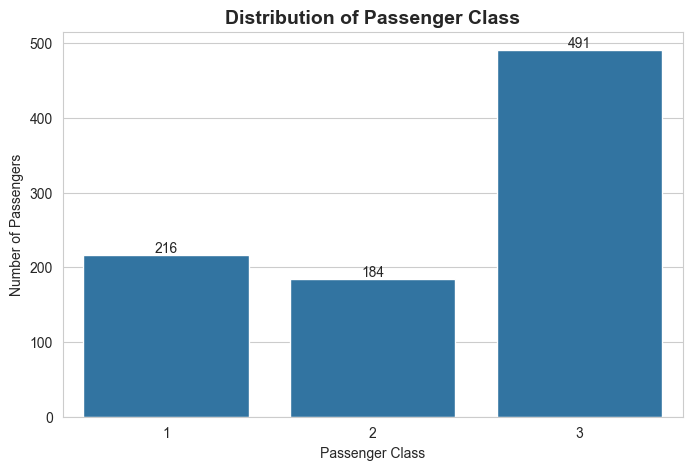

In [18]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Pclass',
    data=df
)

plt.title('Distribution of Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observations

- Third-class passengers constituted the largest group aboard the Titanic.
- First-class passengers represented the smallest proportion of travelers.
- The dataset reflects substantial socioeconomic diversity.
- Passenger class may have influenced survival opportunities.

## 6.5 Gender Distribution

Analyzing the gender composition of passengers provides demographic context for subsequent survival analyses.

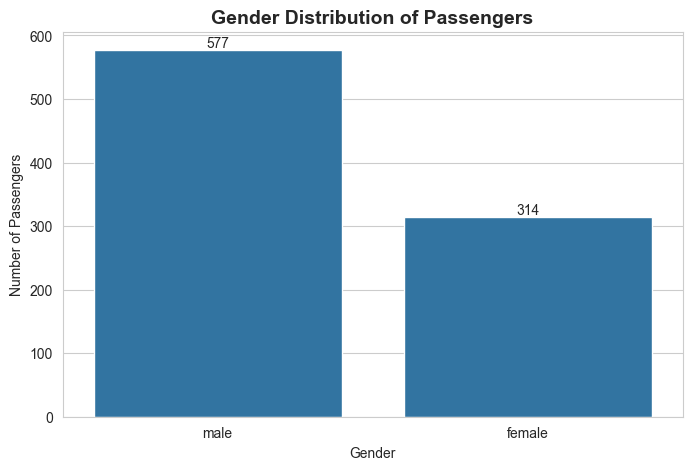

In [19]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Sex',
    data=df
)

plt.title('Gender Distribution of Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observations

- Male passengers outnumbered female passengers aboard the Titanic.
- Gender imbalance within the dataset may influence survival patterns.
- Further analysis is required to determine whether gender affected survival outcomes.

## 6.6 Outlier Detection

Boxplots are used to identify potential outliers in numerical variables while preserving meaningful variability within the data.

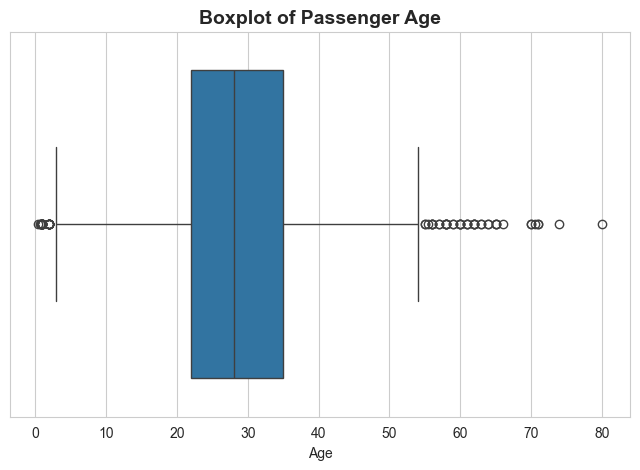

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Age'])

plt.title('Boxplot of Passenger Age', fontsize=14, fontweight='bold')

plt.show()

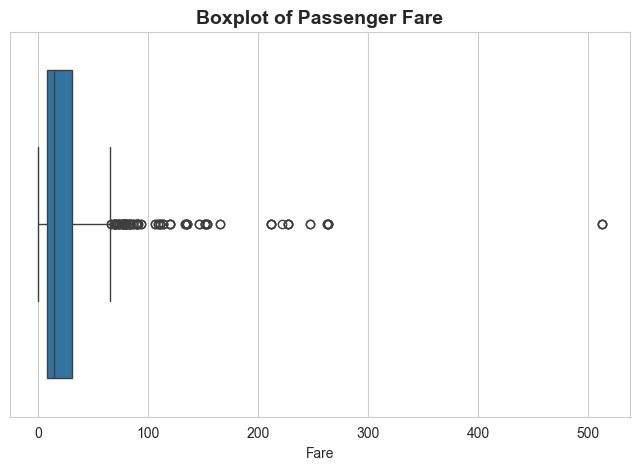

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Fare'])

plt.title('Boxplot of Passenger Fare', fontsize=14, fontweight='bold')

plt.show()

### Observations

- Age contains a few potential outliers representing elderly passengers.
- Fare exhibits numerous extreme values.
- These observations likely reflect genuine passenger characteristics rather than data entry errors.
- Outliers were retained to preserve the authenticity of the exploratory analysis.

## Key Takeaways from Univariate Analysis

- The majority of passengers did not survive the disaster.
- Most passengers were young to middle-aged adults.
- Passenger fares exhibited substantial skewness and numerous outliers.
- Third-class passengers formed the largest travel group.
- Male passengers outnumbered female passengers.
- Several variables identified in this section warrant deeper investigation through relationship analysis.

# 7. Bivariate Analysis

Bivariate analysis examines the relationship between two variables to uncover patterns, associations, and trends that may influence passenger survival outcomes.

The following analyses investigate how demographic and socioeconomic factors affected survival aboard the Titanic.

## 7.1 Survival by Gender

This analysis investigates whether survival outcomes differed between male and female passengers.

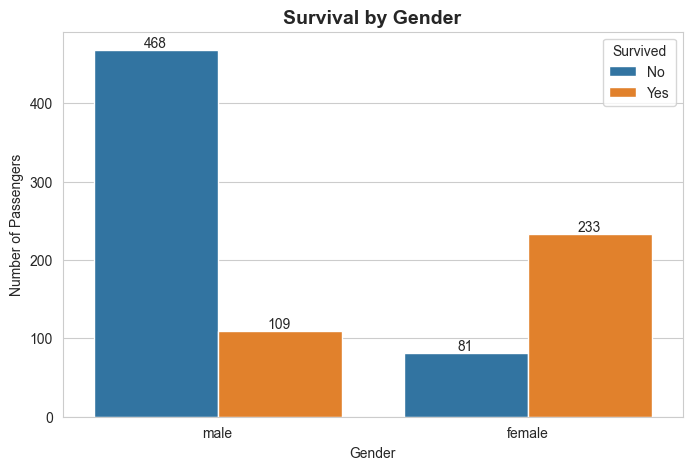

In [25]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.title('Survival by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.legend(title='Survived', labels=['No', 'Yes'])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observations

- Female passengers had substantially higher survival rates than male passengers.
- A large proportion of male passengers did not survive.
- The findings support the historical "women and children first" evacuation practice.
- Gender appears to be a strong predictor of survival.

## 7.2 Survival by Passenger Class

This analysis explores whether socioeconomic status, represented by passenger class, influenced survival outcomes.

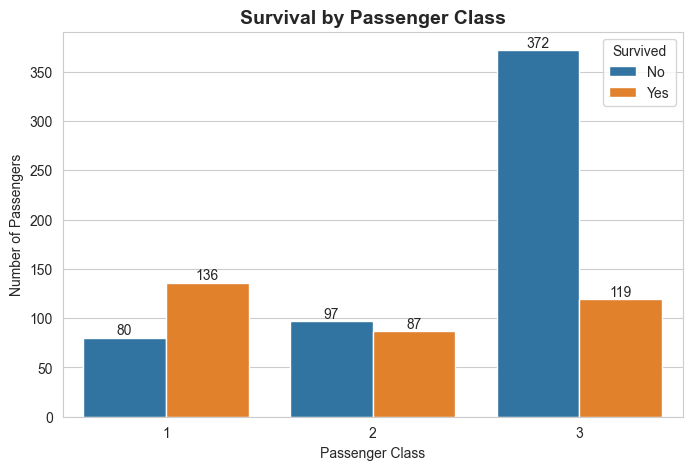

In [26]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Survival by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.legend(title='Survived', labels=['No', 'Yes'])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observations

- First-class passengers exhibited the highest survival rates.
- Third-class passengers experienced the greatest number of fatalities.
- Survival likelihood appears to decline as passenger class decreases.
- The results suggest that socioeconomic status influenced access to safety resources.

## 7.3 Age Distribution by Survival Status

This analysis investigates whether age influenced the probability of survival.

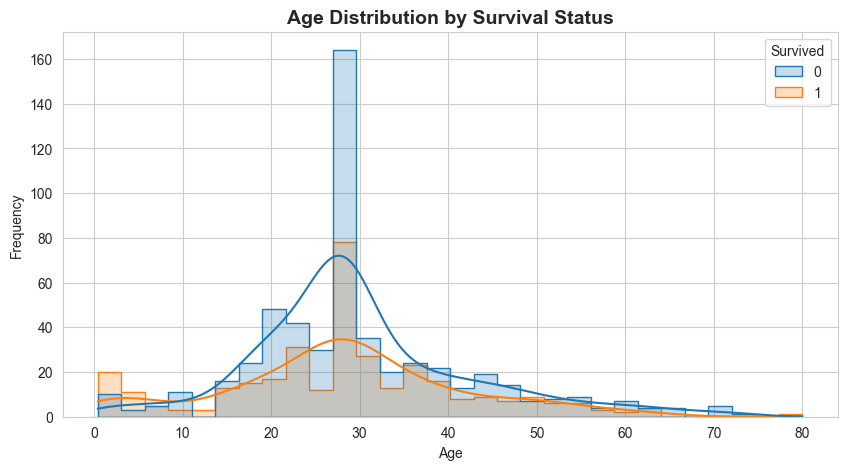

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Survived',
    kde=True,
    bins=30,
    element='step'
)

plt.title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

### Observations

- Children appear to have experienced relatively better survival outcomes.
- Adult passengers accounted for the majority of fatalities.
- The relationship between age and survival is less pronounced than gender or passenger class.
- Age alone may not be a strong determinant of survival.

## 7.4 Survival by Embarkation Port

This analysis examines whether the port of embarkation influenced passenger survival outcomes.

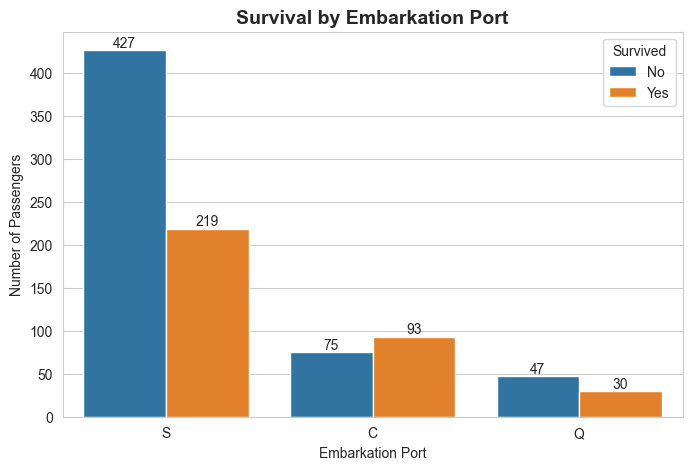

In [28]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived'
)

plt.title('Survival by Embarkation Port', fontsize=14, fontweight='bold')
plt.xlabel('Embarkation Port')
plt.ylabel('Number of Passengers')

plt.legend(title='Survived', labels=['No', 'Yes'])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observations

- Passengers embarking from Southampton constituted the largest group.
- Survival outcomes varied across embarkation ports.
- Differences in passenger composition across ports may explain these patterns.
- Further investigation may be required to determine underlying causes.

## 7.5 Fare by Passenger Class and Survival Status

This scatterplot examines the relationship between passenger class and ticket fare while incorporating survival outcomes. The visualization helps assess whether socioeconomic status influenced survival aboard the Titanic.

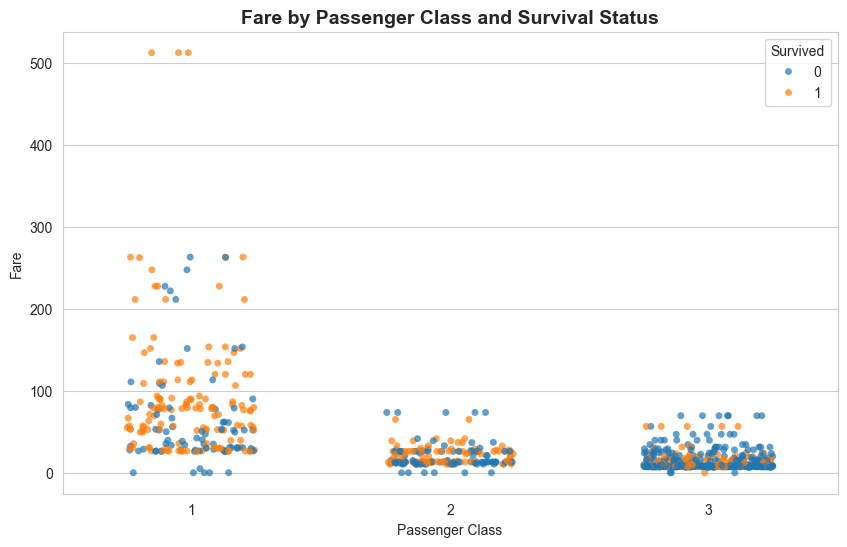

In [32]:
plt.figure(figsize=(10,6))

sns.stripplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived',
    jitter=0.25,
    alpha=0.7
)

plt.title(
    'Fare by Passenger Class and Survival Status',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Passenger Class')
plt.ylabel('Fare')


plt.show()

### Observations

- First-class passengers generally paid substantially higher fares compared to passengers in second and third class.
- Third-class passengers predominantly occupied the lower-fare range and experienced a greater number of fatalities.
- Survivors appear more frequently among first-class passengers, suggesting that socioeconomic status influenced survival outcomes.
- The visualization indicates that passenger class and fare were closely related and together played an important role in determining survival chances aboard the Titanic.

# 8. Pairplot Analysis

A pairplot provides a comprehensive overview of the relationships among important numerical variables in the dataset. By incorporating survival status, it helps identify patterns and potential separations between survivors and non-survivors.

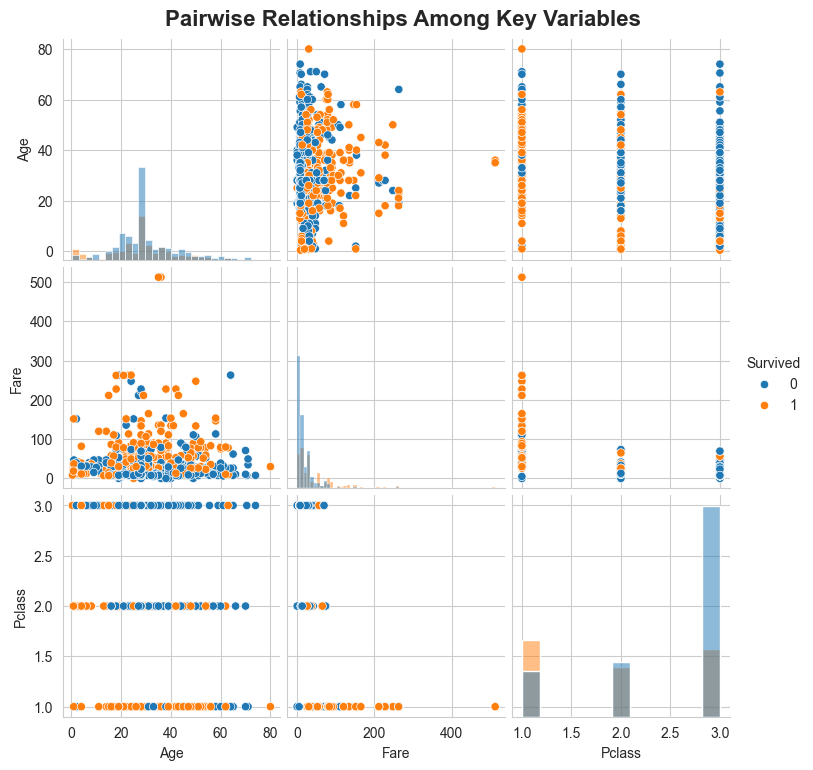

In [33]:
sns.pairplot(
    df[['Survived', 'Age', 'Fare', 'Pclass']],
    hue='Survived',
    diag_kind='hist'
)

plt.suptitle(
    'Pairwise Relationships Among Key Variables',
    y=1.02,
    fontsize=16,
    fontweight='bold'
)

plt.show()

### Observations

- No strong linear relationship was observed between age and fare.
- Passenger class exhibited a clear association with fare, with first-class passengers generally paying higher ticket prices.
- The distributions reinforce previous findings that most passengers paid lower fares and belonged to lower classes.
- Survival groups show some separation with respect to fare and passenger class, suggesting that socioeconomic factors influenced survival outcomes.
- The pairplot provides a consolidated view of relationships explored individually in previous sections.

# 9. Correlation Heatmap

A correlation heatmap provides a visual representation of the relationships between numerical variables in the dataset. It helps identify variables that may be positively or negatively associated with one another.

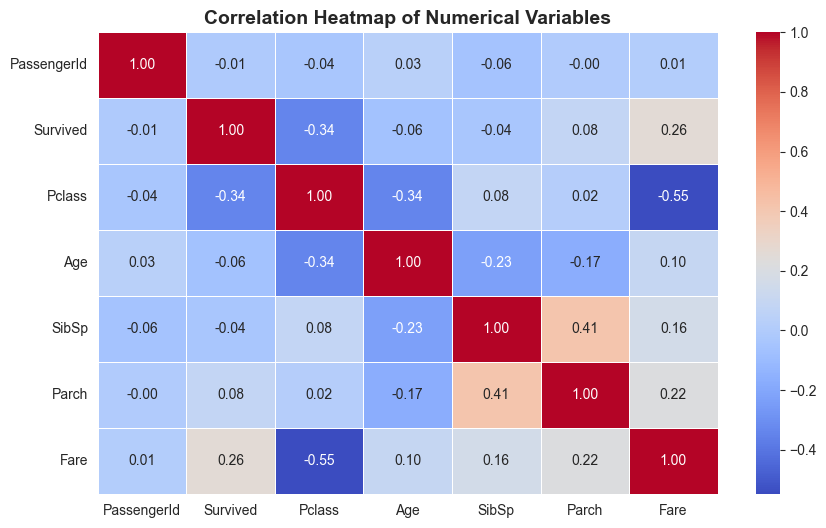

In [34]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap of Numerical Variables',
    fontsize=14,
    fontweight='bold'
)

plt.show()

### Observations

- Passenger class exhibited the strongest relationship with survival, indicating that first-class passengers had higher chances of survival.
- Fare showed a positive association with survival, suggesting that passengers paying higher fares tended to survive more frequently.
- Fare and passenger class were strongly related, reflecting differences in socioeconomic status.
- Age demonstrated only a weak relationship with survival, indicating that it was not a major determinant of passenger outcomes.
- The heatmap findings reinforce insights obtained from previous visual analyses.

# 10. Summary of Findings

The exploratory data analysis of the Titanic dataset revealed several important insights regarding passenger characteristics and survival outcomes:

- Female passengers exhibited significantly higher survival rates compared to male passengers.
- First-class passengers had substantially better chances of survival than passengers in lower classes.
- Third-class passengers constituted the largest passenger group and experienced the highest number of fatalities.
- The majority of passengers were young and middle-aged adults.
- Ticket fares were highly right-skewed, with most passengers paying relatively low fares and a small number paying exceptionally high fares.
- Fare and passenger class were closely related, reflecting socioeconomic differences among passengers.
- Higher ticket fares were generally associated with improved survival outcomes.
- Age demonstrated only a weak relationship with survival, suggesting that it was not a major determinant of passenger outcomes.
- Statistical outliers observed in Age and Fare represented genuine passenger characteristics and were retained for analysis.
- Correlation analysis reinforced the importance of socioeconomic factors in influencing survival aboard the Titanic.

# 11. Conclusion

This project conducted a comprehensive exploratory data analysis of the Titanic dataset using Python libraries including Pandas, Matplotlib, and Seaborn.

Through descriptive statistics, data cleaning, and visual analysis, meaningful patterns and relationships were identified. The analysis demonstrated that factors such as gender, passenger class, and fare played a significant role in determining survival outcomes, while age exhibited a comparatively weaker influence.

The findings highlight the impact of socioeconomic status on survival during the Titanic disaster and illustrate how exploratory data analysis can uncover valuable insights from historical datasets.

Overall, this project strengthened practical skills in data preprocessing, visualization, statistical interpretation, and communicating analytical findings using a structured and professional workflow.